# Assignment 4: Student Exam Score Prediction, Study Habits Dataset

**Anshuman Atrey** · Roll No. 150096724029 · B.Tech CSE 2024-28, Semester V · Machine Learning Fundamentals (Google Classroom, ML(Elon Musk))

| | |
|---|------------------|
| **dataset** | [Student Habits vs Academic Performance](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance) on kaggle: 1,000 students, 16 columns |
| **my subset** | gender matching mine (**male**: 477 students). the extra rule "study hours >= 5" (roll number mod 5, plus 1) left only 80 students, fewer than 150, so as the handout says it was dropped |
| **target** | `exam_score` (0 to 100) |
| **model** | Linear Regression on study hours plus the other daily habits |
| **result** | **test R-squared 0.916** (train 0.905, 5-fold cross-validation 0.898 ± 0.012), pass condition 0.70 |

## the whole thing in plain words

for anyone who has never touched machine learning:

1. **The task:** predict a student's exam score (out of 100) from their daily habits, like study hours, sleep and social media, using Linear Regression.
2. **My slice of the data:** the handout filters by my own gender (male) and by study hours of at least 5 a day. That second rule left only 80 students, under the 150 minimum, so it was dropped, leaving 477 male students.
3. **Cleaning:** the data was already tidy. 37 students had no parental education listed, so they got an honest "Unknown" instead of a guess.
4. **The scores:** most students land between 55 and 85, the middle is 70, and 22 students hit a perfect 100.
5. **Study time is the big one:** every extra hour of study a day goes with about 9.6 more marks, and study hours alone explain about 70% of the differences in scores.
6. **Sleep matters too:** students who sleep 7 to 8 hours average 74, while those under 5 hours average 65.
7. **Part-time jobs cost a little:** about 2 marks lower on average, a smaller effect than you'd expect.
8. **Why more habits helped so much:** the habits barely move together, so each one adds new information. Going from 4 habits to all 7 took the score from 75% to 92%.
9. **The final score:** test R² 0.916 on students the model never saw (the pass mark was 0.70). Training R² is 0.905, and 5 different splits average 0.898, so it isn't memorising.
10. **What it learned:** per hour, study adds about 9.6 marks, while social media and Netflix take away about 2.3 and 2.2. Mental health adds about 2 marks per rating point.
11. **Limitations:** the typical error is about 4 marks, and scores can't go above 100, so the very best students are a little harder to predict.
12. **What gets handed in:** the notebook, a 1-page summary PDF, and this report (PDF and Word) with every step's explanation, code and output screenshot.

## 1. setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42                                  # same split every run
ROLL_NUMBER = 150096724029
FIG = Path("figures")
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.2 | numpy 2.2.6


## 2. loading the data and personalising the subset

the handout: keep the rows where gender matches mine (male), and study hours >= (roll number mod 5) + 1. if that leaves fewer than 150 students, drop the study-hours rule and keep the gender filter only.

In [2]:
students = pd.read_csv("data/student_habits_performance.csv")
print(f"full dataset: {students.shape[0]} rows x {students.shape[1]} columns")
print("gender:", students["gender"].value_counts().to_dict())

min_hours = ROLL_NUMBER % 5 + 1
male = students["gender"] == "Male"
both = male & (students["study_hours_per_day"] >= min_hours)
print(f"\nmale: {male.sum()} | male and study hours >= {min_hours}: {both.sum()} "
      f"-> {'fewer than 150, so the study-hours rule is dropped' if both.sum() < 150 else 'kept'}")
data = students[both if both.sum() >= 150 else male].copy()
print(f"my subset: {len(data)} students")
data.head()

full dataset: 1000 rows x 16 columns
gender: {'Female': 481, 'Male': 477, 'Other': 42}

male: 477 | male and study hours >= 5: 80 -> fewer than 150, so the study-hours rule is dropped
my subset: 477 students


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
5,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
11,S1011,23,Male,3.9,2.4,2.5,No,71.7,7.9,Fair,2,Bachelor,Average,1,No,74.4
14,S1014,24,Male,2.4,1.5,0.7,No,87.4,6.7,Poor,6,Bachelor,Average,9,No,78.9
15,S1015,21,Male,3.1,5.0,1.0,No,97.5,6.5,Good,6,High School,Average,7,No,74.0


## 3. EDA: missing values, duplicates, outliers

In [3]:
print("missing values:", data.isna().sum()[lambda s: s > 0].to_dict())
print("duplicate rows:", int(data.duplicated().sum()), "| duplicate student ids:", int(data["student_id"].duplicated().sum()))

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return int(((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).sum())

print(f"outliers by the 1.5 x IQR rule: exam_score {iqr_outliers(data['exam_score'])}, "
      f"study_hours {iqr_outliers(data['study_hours_per_day'])}")
print("students with a perfect 100:", int((data["exam_score"] == 100).sum()))
data.describe().round(1).T[["mean", "min", "50%", "max"]]

missing values: {'parental_education_level': 37}
duplicate rows: 0 | duplicate student ids: 0
outliers by the 1.5 x IQR rule: exam_score 1, study_hours 3
students with a perfect 100: 22


,mean,min,50%,max
age,20.6,17.0,21.0,24.0
study_hours_per_day,3.5,0.0,3.5,8.3
social_media_hours,2.5,0.0,2.5,7.2
netflix_hours,1.8,0.0,1.8,4.9
attendance_percentage,83.9,59.7,83.9,100.0
sleep_hours,6.4,3.3,6.5,10.0
exercise_frequency,3.2,0.0,3.0,6.0
mental_health_rating,5.4,1.0,5.0,10.0
exam_score,69.4,23.1,70.2,100.0


477 male students and 16 columns. the only missing values are 37 in `parental_education_level`. there are no duplicate rows or repeated student ids. the IQR rule finds almost no outliers (1 exam score, 3 study-hour values), and all values look possible (0 to 8.3 study hours a day, scores 23 to 100). one thing to remember: 22 students scored exactly 100, the maximum, so scores pile up at the top.

## 4. cleaning

- **missing values:** only `parental_education_level` has gaps. guessing a parent's education would be making data up, so the gaps become their own category, "Unknown"
- **encoding:** the text columns (part-time job, diet, parental education, internet quality, extracurriculars) get one-hot encoded (one 0/1 column per value) when they go into the model
- **gender** is now the same for every row (male), so it carries no information and drops out
- `student_id` is just a label, not a habit, so it stays out of the model

In [4]:
data["parental_education_level"] = data["parental_education_level"].fillna("Unknown")
TEXT = ["part_time_job", "diet_quality", "parental_education_level", "internet_quality",
        "extracurricular_participation"]
HABITS = ["study_hours_per_day", "social_media_hours", "netflix_hours", "attendance_percentage",
          "sleep_hours", "exercise_frequency", "mental_health_rating", "age"]
print("missing values left:", int(data.isna().sum().sum()))
print("parental_education_level:", data["parental_education_level"].value_counts().to_dict())

missing values left: 0
parental_education_level: {'High School': 194, 'Bachelor': 165, 'Master': 81, 'Unknown': 37}


## 5. visualisations

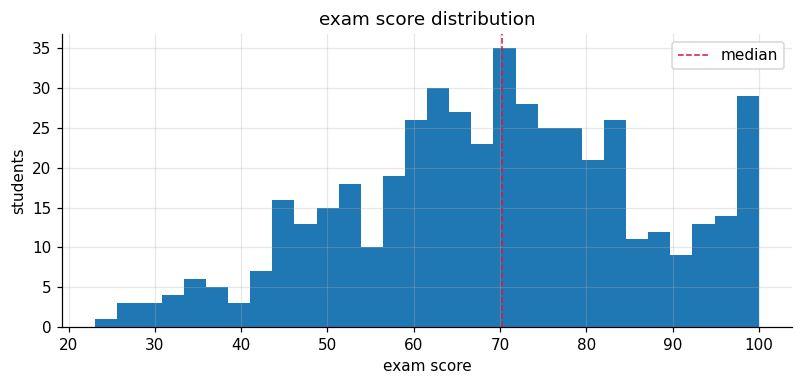

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.hist(data["exam_score"], bins=30, color="tab:blue")
ax.axvline(data["exam_score"].median(), color="crimson", ls="--", lw=1, label="median")
ax.set(title="exam score distribution", xlabel="exam score", ylabel="students")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "01_score_distribution.png", bbox_inches="tight")
plt.show()

scores spread widely, mostly between 55 and 85, with a median of 70.2. the bar at 100 is the 22 students who hit the maximum: the real score of a top student could be "more than 100", but the exam stops there. thats a ceiling a straight-line model cant see.

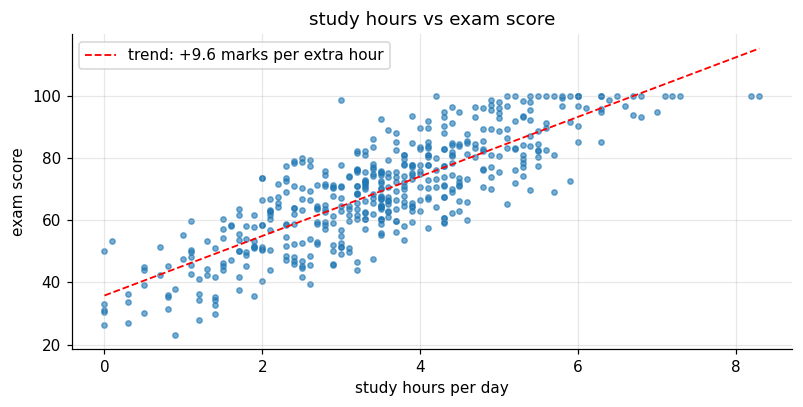

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.scatter(data["study_hours_per_day"], data["exam_score"], s=12, alpha=0.6)
slope, intercept = np.polyfit(data["study_hours_per_day"], data["exam_score"], 1)
xs = np.linspace(0, data["study_hours_per_day"].max(), 50)
ax.plot(xs, slope * xs + intercept, "r--", lw=1.2, label=f"trend: +{slope:.1f} marks per extra hour")
ax.set(title="study hours vs exam score", xlabel="study hours per day", ylabel="exam score")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "02_study_hours_vs_score.png", bbox_inches="tight")
plt.show()

the clearest pattern in the data: more study hours, higher score, about **+9.6 marks for every extra hour a day**. study hours alone correlate 0.83 with the score. the dots still scatter around the line, so the other habits must explain the rest.

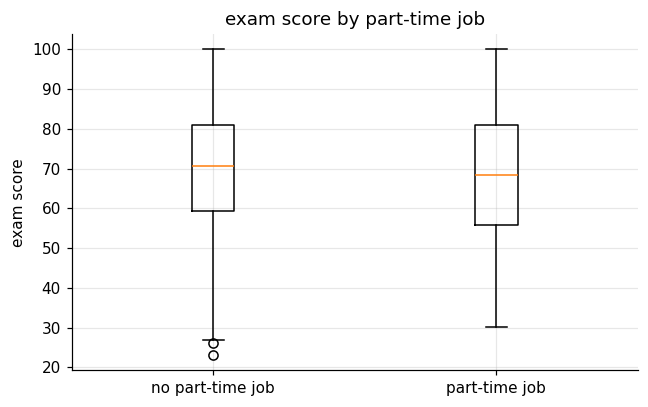

               count  mean  median
part_time_job                     
No               368  69.8    70.7
Yes              109  67.9    68.3


In [7]:
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.boxplot([data.loc[data["part_time_job"] == v, "exam_score"] for v in ("No", "Yes")])
ax.set_xticks([1, 2], ["no part-time job", "part-time job"])
ax.set(title="exam score by part-time job", ylabel="exam score")
plt.tight_layout()
plt.savefig(FIG / "03_score_by_part_time_job.png", bbox_inches="tight")
plt.show()
print(data.groupby("part_time_job")["exam_score"].agg(["count", "mean", "median"]).round(1).to_string())

students with a part-time job score a little lower: 67.9 on average against 69.8 (medians 68.3 and 70.7). about 2 marks, much smaller than the study-hours effect, and the two boxes overlap almost completely.

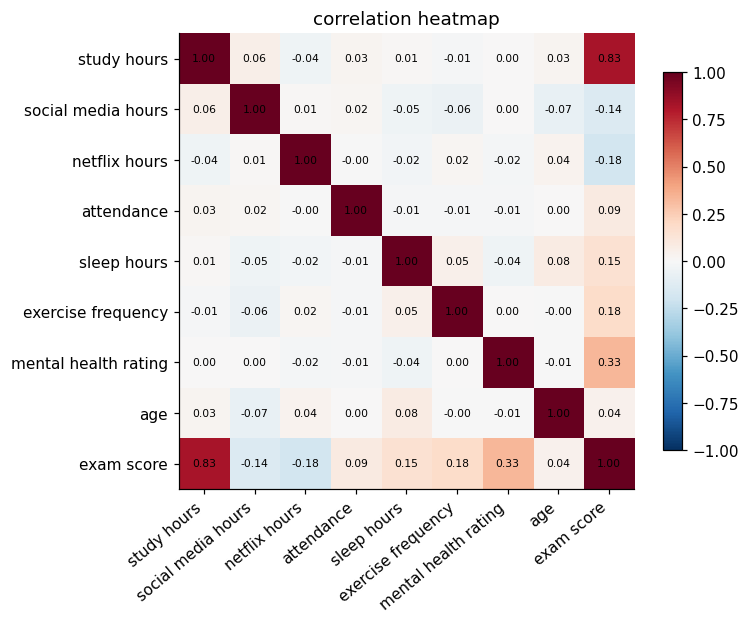

In [8]:
corr = data[HABITS + ["exam_score"]].corr()
fig, ax = plt.subplots(figsize=(7, 5.8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
labels = [c.replace("_per_day", "").replace("_percentage", "").replace("_", " ") for c in corr.columns]
ax.set_xticks(range(len(corr)), labels, rotation=40, ha="right")
ax.set_yticks(range(len(corr)), labels)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("correlation heatmap")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIG / "04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

study hours (0.83) and mental health (0.33) move most with the score. social media (-0.14) and netflix (-0.18) pull it down a bit, sleep (0.15) and exercise (0.18) push it up a bit, and age says almost nothing (0.04). the key detail: the habits hardly move together (no pair above 0.08), so each one brings new information. thats why adding them all makes such a big jump in section 6.

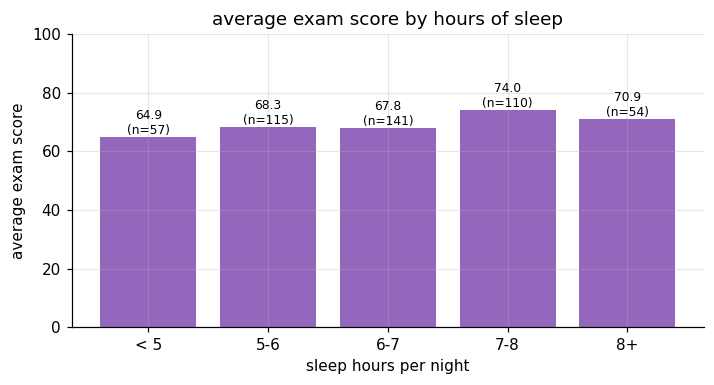

In [9]:
buckets = pd.cut(data["sleep_hours"], bins=[0, 5, 6, 7, 8, 24], labels=["< 5", "5-6", "6-7", "7-8", "8+"],
                 right=False)
by_sleep = data.groupby(buckets, observed=True)["exam_score"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.bar(by_sleep.index.astype(str), by_sleep["mean"], color="tab:purple")
for i, (m, n) in enumerate(zip(by_sleep["mean"], by_sleep["count"])):
    ax.text(i, m, f"{m:.1f}\n(n={n})", ha="center", va="bottom", fontsize=8)
ax.set(title="average exam score by hours of sleep", xlabel="sleep hours per night",
       ylabel="average exam score", ylim=(0, 100))
plt.tight_layout()
plt.savefig(FIG / "05_score_by_sleep.png", bbox_inches="tight")
plt.show()

7 to 8 hours of sleep goes with the best average, 74.0, and under 5 hours with the worst, 64.9, about 9 marks apart. sleeping more than 8 hours doesnt help further (70.9).

## 6. building and refining the model

the handout: predict exam score from study hours plus at least 3 other features, 80/20 split, report R-squared and RMSE on the test set, and refine (feature scaling, dropping weak features, handling outliers) until test R-squared reaches 0.70. each version below adds or removes one thing, and every one also gets 5-fold cross-validation (5 different splits), because one split of 96 test students can be lucky.

In [10]:
def evaluate(columns, text=(), scale=False):
    """80/20 split + 5-fold CV for a Linear Regression on these columns (text columns one-hot encoded)."""
    X = pd.get_dummies(data[list(columns) + list(text)], columns=list(text), drop_first=True, dtype=float)
    y = data["exam_score"]
    model = make_pipeline(StandardScaler(), LinearRegression()) if scale else LinearRegression()
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
    model.fit(X_tr, y_tr)
    cv = cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")
    pred = model.predict(X_te)
    scores = {"features": X.shape[1], "train R2": r2_score(y_tr, model.predict(X_tr)),
              "test R2": r2_score(y_te, pred), "5-fold CV R2": cv.mean(), "CV spread": cv.std(),
              "test RMSE": np.sqrt(mean_squared_error(y_te, pred)), "test MAE": mean_absolute_error(y_te, pred)}
    return scores, model, X, (y_te, pred)


STRONG = ["study_hours_per_day", "social_media_hours", "netflix_hours", "attendance_percentage",
          "sleep_hours", "exercise_frequency", "mental_health_rating"]
versions = [("v1 study hours only", ["study_hours_per_day"], (), False),
            ("v2 + sleep, attendance, social media", ["study_hours_per_day", "sleep_hours",
             "attendance_percentage", "social_media_hours"], (), False),
            ("v3 + all daily habits", HABITS, (), False),
            ("v4 + the text columns (encoded)", HABITS, TEXT, False),
            ("v5 weak features dropped (final)", STRONG, (), False),
            ("v6 same as v5, features scaled", STRONG, (), True)]
rows = []
for name, columns, text, scale in versions:
    scores, *_ = evaluate(columns, text, scale)
    rows.append({"version": name, **scores})
table = pd.DataFrame(rows).set_index("version")
table.round(3)

,features,train R2,test R2,5-fold CV R2,CV spread,test RMSE,test MAE
version,,,,,,,
v1 study hours only,1,0.674,0.710,0.658,0.060,9.596,8.062
"v2 + sleep, attendance, social media",4,0.737,0.752,0.713,0.049,8.888,7.446
v3 + all daily habits,8,0.905,0.916,0.897,0.012,5.172,4.170
v4 + the text columns (encoded),17,0.907,0.913,0.896,0.011,5.274,4.230
v5 weak features dropped (final),7,0.905,0.916,0.898,0.012,5.166,4.166
"v6 same as v5, features scaled",7,0.905,0.916,0.898,0.012,5.166,4.166


- **v1, study hours only:** test R² 0.710, already just past the 0.70 bar, but cross-validation says 0.658, so on other splits it would fail
- **v2, the handout minimum (study hours + 3 more):** 0.752, CV 0.713
- **v3, all 8 daily habits:** the big jump, test 0.916 and CV 0.897. because the habits are nearly independent, each one explains a different slice of the score
- **v4, adding the text columns** (diet, parental education, internet, part-time job, extracurriculars): no gain (0.913), so theyre weak or noisy
- **v5, weak features dropped:** age and the text columns removed, 7 features left. same score with fewer features, the simplest strong model, so its the final one
- **v6, feature scaling:** exactly the same R². scaling doesnt change what a linear regression can fit, it only puts the coefficients on the same scale, which section 7 uses to compare habits fairly

## 7. checking the final model

final model (v5): train R2 0.905 | test R2 0.916 | gap -0.011
5-fold cross-validation R2: 0.898 +- 0.012
test RMSE 5.17 marks | test MAE 4.17 marks


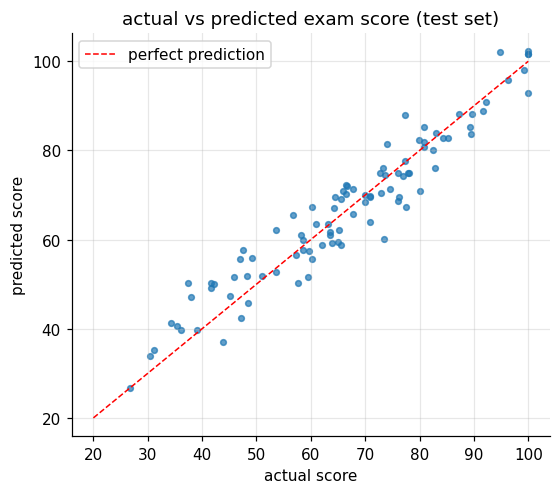

In [11]:
final, model, X_all, (actual, pred) = evaluate(STRONG)
train_r2, test_r2 = final["train R2"], final["test R2"]
print(f"final model (v5): train R2 {train_r2:.3f} | test R2 {test_r2:.3f} | gap {train_r2 - test_r2:+.3f}")
print(f"5-fold cross-validation R2: {final['5-fold CV R2']:.3f} +- {final['CV spread']:.3f}")
print(f"test RMSE {final['test RMSE']:.2f} marks | test MAE {final['test MAE']:.2f} marks")

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(actual, pred, s=14, alpha=0.7)
ax.plot([20, 100], [20, 100], "r--", lw=1, label="perfect prediction")
ax.set(title="actual vs predicted exam score (test set)", xlabel="actual score", ylabel="predicted score")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "06_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

In [12]:
raw = pd.Series(model.coef_, index=X_all.columns)
scaled_model = make_pipeline(StandardScaler(), LinearRegression()).fit(X_all, data["exam_score"])
per_sd = pd.Series(scaled_model[-1].coef_, index=X_all.columns)
habits = pd.DataFrame({"marks per 1 unit": raw, "marks per 1 typical change (1 std)": per_sd})
habits.index = [c.replace("_per_day", "").replace("_percentage", " %").replace("_", " ") for c in habits.index]
habits.sort_values("marks per 1 typical change (1 std)", key=abs, ascending=False).round(2)

,marks per 1 unit,marks per 1 typical change (1 std)
study hours,9.58,14.22
mental health rating,2.04,5.76
exercise frequency,1.48,3.07
social media hours,-2.30,-2.89
netflix hours,-2.15,-2.40
sleep hours,1.92,2.36
attendance %,0.15,1.40


train R² 0.905 against test R² 0.916, so theres no overfitting, and 5 different splits give 0.898 ± 0.012. the typical error (MAE) is 4.2 marks. the dots hug the diagonal, with a little squeeze at the top because scores stop at 100.

what each habit is worth (holding the others fixed), and per "typical change" (1 standard deviation) so habits measured in different units can be compared fairly:

- **study hours:** +9.6 marks per extra hour, +14.2 per typical change. by far the strongest
- **mental health rating:** +2.0 per point, +5.8 per typical change, a clear second
- **exercise:** +1.5 per weekly session, +3.1 per typical change
- **social media and netflix:** -2.3 and -2.2 marks per daily hour
- **sleep:** +1.9 per hour
- **attendance:** +0.15 per percent, the smallest effect

## 8. summary

**which habits affected exam performance the most.** in my subset of 477 male students, **study time** dominates: every extra hour a day goes with about 9.6 more marks, holding the other habits fixed, and study hours alone explain about 70% of the score differences. **mental health** is a clear second (+2 marks per rating point on a 1 to 10 scale), then **exercise** (+1.5 per weekly session) and **sleep** (+1.9 per hour, with 7 to 8 hours the best band, 74 marks on average against 65 under 5 hours). **screen time** pulls scores down: about -2.3 marks per daily hour of social media and -2.2 per hour of netflix. a part-time job costs only about 2 marks, and attendance barely matters in this data.

**why the final model performs as it does.** the habits hardly move together (no pair correlates above 0.08), so each one explains a different slice of the score, and a straight line on 7 habits fits very well: test R² 0.916, train 0.905, cross-validation 0.898 ± 0.012. scaling didnt change the score (it never does for linear regression), but it let me compare habits measured in hours, percent and ratings on one scale.

**limits.** the data looks synthetic (very clean, habits almost independent), so real students would be messier. scores are capped at 100, which squeezes the top end, and the typical error is about 4 marks.

In [13]:
summary = pd.Series({
    "subset": f"male students, {len(data)} rows (study-hours rule dropped, it left {both.sum()})",
    "final model": "Linear Regression on 7 daily habits",
    "train R2 / test R2": f"{train_r2:.3f} / {test_r2:.3f}",
    "5-fold cross-validation R2": f"{final['5-fold CV R2']:.3f} +- {final['CV spread']:.3f}",
    "test RMSE / MAE": f"{final['test RMSE']:.2f} / {final['test MAE']:.2f} marks",
    "pass condition (test R2 >= 0.70)": "passed" if test_r2 >= 0.70 else "not passed",
}, name="value")
summary.to_frame()

,value
subset,"male students, 477 rows (study-hours rule drop..."
final model,Linear Regression on 7 daily habits
train R2 / test R2,0.905 / 0.916
5-fold cross-validation R2,0.898 +- 0.012
test RMSE / MAE,5.17 / 4.17 marks
pass condition (test R2 >= 0.70),passed
